# Paddy Disease Model
This notebook develops the Paddy Disease Classification model using the
reusable data and training components implemented in `src/`.

We begin by reproducing the baseline configuration established in
`02_baseline_model.ipynb`, but train it for 15 epochs. This provides a
stronger baseline before introducing changes to the model or training
strategy.

## 1. Project Setup
We define the libraries, computation device, and reusable project components
used throughout this notebook.

### 1.1: Import Libraries

In [1]:
import sys
from pathlib import Path

import torch
from torch import nn

from torchvision.models import (
    efficientnet_v2_s,
    EfficientNet_V2_S_Weights
)

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# project modules
from src.data import (
    train_loader,
    val_loader,
    NUM_CLASSES,
    CLASS_NAMES
)

from src.engine import Trainer

from src.evaluation import (
    get_predictions,
    calculate_accuracy,
    calculate_f1_scores,
    calculate_macro_f1,
    calculate_confusion_matrix
)

Training samples: 8325
Validation samples: 2082


### 1.2: Choose Device

In [2]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: mps


## 1.3: Load EfficientNetV2-S

In [3]:
weights = EfficientNet_V2_S_Weights.DEFAULT

model = efficientnet_v2_s(weights=weights)

model.classifier[1] = nn.Linear(
    in_features=model.classifier[1].in_features,
    out_features=NUM_CLASSES
)

for parameter in model.features.parameters():
    parameter.requires_grad = False

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


## 2. Baseline Model
We reconstruct the baseline EfficientNetV2-S model using the pretrained
ImageNet weights.

The model architecture and classification head are kept consistent with the
baseline established in the previous notebook.

## 2.1: Baseline Training
We train the reconstructed baseline model for 15 epochs using the reusable
training implementation from `src.engine`.

In [ ]:
# configure training
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3
)

NUM_EPOCHS = 15

In [ ]:
# instantiate the trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device
)

In [ ]:
# train the baseline model 
history = trainer.fit(NUM_EPOCHS)

### 2.2 Evaluate the 15-Epoch Baseline
We evaluate the 15-epoch baseline using the same metrics used in the
5-epoch experiment.

This allows us to determine whether the additional training improved
classification performance rather than relying on validation loss alone.

In [ ]:
predictions, labels = get_predictions(
    model,
    val_loader,
    device
)

accuracy = calculate_accuracy(
    predictions,
    labels
)

macro_f1 = calculate_macro_f1(
    predictions,
    labels,
    NUM_CLASSES
)

confusion_matrix = calculate_confusion_matrix(
    predictions,
    labels,
    NUM_CLASSES
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

### 2.3 Analyze Baseline Errors
Overall accuracy and macro F1 do not reveal how the model performs on
individual disease classes.
We therefore examine the F1 score for each class to identify classes that
are particularly difficult for the baseline model.

In [ ]:
import importlib
import src.evaluation

importlib.reload(src.evaluation)
from src.evaluation import calculate_f1_scores

In [ ]:
f1 = calculate_f1_scores(
    predictions,
    labels,
    NUM_CLASSES
)
for class_name, class_f1 in zip(CLASS_NAMES, f1):
    print(f"{class_name:<28} F1: {class_f1.item():.4f}")

### 2.4: Save the 15-Epoch Baseline
We save the trained baseline model together with the optimizer state,
training history, and epoch number.

The checkpoint allows training to be resumed later without repeating the
15 epochs already completed.

In [ ]:
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
}

checkpoint_path = models_dir / "efficientnet_v2_s_baseline_15epochs.pth"

torch.save(checkpoint, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")

## 3. Fine Tuning

### 3.1: Unfreeze the last one layer

verify the number of trainable parameters:

In [ ]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")

inspect the layers:

In [ ]:
for name, module in model.features.named_children():
    print(name, type(module).__name__)

finally unfreeze layers 5, 6, and 7:

In [ ]:
for parameter in model.features.parameters():
    parameter.requires_grad = False

for parameter in model.features[7:].parameters():
    parameter.requires_grad = True

check the parameters:

In [ ]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")

### 3.2: Configure the Fine-Tuning Optimizer

In [ ]:
optimizer = torch.optim.AdamW([
    {
        "params": model.features[6:].parameters(),
        "lr": 1e-5
    },
    {
        "params": model.classifier.parameters(),
        "lr": 1e-4
    }
])

In [ ]:
criterion = nn.CrossEntropyLoss()

### 3.3: Train the Fine-Tuned Model

In [ ]:
NUM_EPOCHS = 5

In [ ]:
checkpoint_path = (
    PROJECT_ROOT
    / "models"
    / "efficientnet_v2_s_finetuned_best.pth"
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    checkpoint_path=checkpoint_path
)

In [ ]:
history_finetuning = trainer.fit(NUM_EPOCHS)

We are now training after 5 epochs. Load the saved checkpoint:

In [ ]:
checkpoint = trainer.load_checkpoint(checkpoint_path)

print(f"Loaded checkpoint from epoch: {checkpoint['epoch']}")
print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")

In [ ]:
NUM_EPOCHS = 15

history_finetuning = trainer.fit(NUM_EPOCHS)

### 3.4: Evaluate Fine-Tuned Model

In [ ]:
predictions, labels = get_predictions(
    model,
    val_loader,
    device
)

accuracy = calculate_accuracy(
    predictions,
    labels
)

macro_f1 = calculate_macro_f1(
    predictions,
    labels,
    NUM_CLASSES
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

fet the per-class F1:

In [ ]:
f1_scores = calculate_f1_scores(
    predictions,
    labels,
    NUM_CLASSES
)

for class_name, f1_score in zip(CLASS_NAMES, f1_scores):
    print(f"{class_name}: {f1_score:.4f}")

Train further for five more epochs:

In [ ]:
NUM_EPOCHS = 5

history_finetuning = trainer.fit(NUM_EPOCHS) 

Evaluate again:

In [ ]:
predictions, labels = get_predictions(
    model,
    val_loader,
    device
)

accuracy = calculate_accuracy(
    predictions,
    labels
)

macro_f1 = calculate_macro_f1(
    predictions,
    labels,
    NUM_CLASSES
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

get per-class F-1

In [ ]:
f1_scores = calculate_f1_scores(
    predictions,
    labels,
    NUM_CLASSES
)

for class_name, f1_score in zip(CLASS_NAMES, f1_scores):
    print(f"{class_name}: {f1_score:.4f}")

Train again for ten more epochs:

In [ ]:
NUM_EPOCHS = 10

history_finetuning = trainer.fit(NUM_EPOCHS) 

evaluate:

In [ ]:
predictions, labels = get_predictions(
    model,
    val_loader,
    device
)

accuracy = calculate_accuracy(
    predictions,
    labels
)

macro_f1 = calculate_macro_f1(
    predictions,
    labels,
    NUM_CLASSES
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

per class F-1:

In [ ]:
f1_scores = calculate_f1_scores(
    predictions,
    labels,
    NUM_CLASSES
)

for class_name, f1_score in zip(CLASS_NAMES, f1_scores):
    print(f"{class_name}: {f1_score:.4f}")

get the best checkpoint:

In [9]:
checkpoint = trainer.load_checkpoint(checkpoint_path)

print(f"Loaded checkpoint from epoch: {checkpoint['epoch']}")
print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")

Loaded checkpoint from epoch: 7
Best validation loss: 0.3213


Rerun the evaluation cell:

In [ ]:
predictions, labels = get_predictions(
    model,
    val_loader,
    device
)

accuracy = calculate_accuracy(
    predictions,
    labels
)

macro_f1 = calculate_macro_f1(
    predictions,
    labels,
    NUM_CLASSES
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

### 3.5 Compare with Baseline
The fine-tuned model is compared with the frozen-backbone baseline using
validation accuracy and macro F1.

In [ ]:
baseline_accuracy = 0.6888
baseline_macro_f1 = 0.6563

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Fine-Tuned Accuracy: {accuracy:.4f}")
print(f"Accuracy Improvement: {(accuracy - baseline_accuracy) * 100:.2f} percentage points")

print()

print(f"Baseline Macro F1: {baseline_macro_f1:.4f}")
print(f"Fine-Tuned Macro F1: {macro_f1:.4f}")
print(f"Macro F1 Improvement: {(macro_f1 - baseline_macro_f1) * 100:.2f} percentage points")

### 3.6 Fine-Tuning Conclusion

Fine-tuning the final feature stage of EfficientNetV2-S together with the
classification head improved performance over the frozen-backbone baseline.

The best fine-tuned checkpoint occurred at epoch 34, with a validation loss
of 0.8952.

The fine-tuned model achieved:

- Validation Accuracy: 70.80%
- Validation Macro F1: 67.36%

The frozen-backbone baseline achieved:

- Validation Accuracy: 68.88%
- Validation Macro F1: 65.63%

Thus, fine-tuning the final feature stage improved validation accuracy by
1.92 percentage points and macro F1 by 1.73 percentage points.

The experiment suggests that adapting the higher-level pretrained
representation to the Paddy Doctor dataset is beneficial, while retaining
the earlier pretrained feature stages.

## 4. Fine-Tuning Earlier Feature Stages

### 4.1 Unfreeze Stage 6

In [4]:
for parameter in model.features.parameters():
    parameter.requires_grad = False

for parameter in model.features[6:].parameters():
    parameter.requires_grad = True

check the parameters:

In [5]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")

Trainable parameters: 14,904,882
Total parameters: 20,190,298


### 4.2: Configure The Fine-Tuning Optimizer

In [6]:
optimizer = torch.optim.AdamW([
    {
        "params": model.features[6:].parameters(),
        "lr": 1e-5
    },
    {
        "params": model.classifier.parameters(),
        "lr": 1e-4
    }
])

In [7]:
criterion = nn.CrossEntropyLoss()

### 4.3: Train the [6: ] Model

create checkpoint path:

In [8]:
checkpoint_path = (
    PROJECT_ROOT
    / "models"
    / "efficientnet_v2_s_finetuned_stage6_best.pth"
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    checkpoint_path=checkpoint_path
)

In [ ]:
NUM_EPOCHS = 5

history_stage6 = trainer.fit(NUM_EPOCHS)

evaluate it:

In [ ]:
predictions, labels = get_predictions(
    model,
    val_loader,
    device
)

accuracy = calculate_accuracy(
    predictions,
    labels
)

macro_f1 = calculate_macro_f1(
    predictions,
    labels,
    NUM_CLASSES
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

In [ ]:
f1_scores = calculate_f1_scores(
    predictions,
    labels,
    NUM_CLASSES
)

for class_name, f1_score in zip(CLASS_NAMES, f1_scores):
    print(f"{class_name}: {f1_score:.4f}")

Let's continue for five more epochs:

In [10]:
NUM_EPOCHS = 5

history_stage6 = trainer.fit(NUM_EPOCHS)

Training Progress:  58%|#####8    | 7/12 [00:00<?, ?epoch/s]

Epoch 8/12 Training:   0%|          | 0/261 [00:00<?, ?batch/s]

Epoch 8/12 Validation:   0%|          | 0/66 [00:00<?, ?batch/s]

Epoch 9/12 Training:   0%|          | 0/261 [00:00<?, ?batch/s]

Epoch 9/12 Validation:   0%|          | 0/66 [00:00<?, ?batch/s]

...

Epoch 10/12 Validation:   0%|          | 0/66 [00:00<?, ?batch/s]

Epoch 11/12 Training:   0%|          | 0/261 [00:00<?, ?batch/s]

Epoch 11/12 Validation:   0%|          | 0/66 [00:00<?, ?batch/s]

Epoch 12/12 Training:   0%|          | 0/261 [00:00<?, ?batch/s]

Epoch 12/12 Validation:   0%|          | 0/66 [00:00<?, ?batch/s]

evaluate it:

In [11]:
predictions, labels = get_predictions(
    model,
    val_loader,
    device
)

accuracy = calculate_accuracy(
    predictions,
    labels
)

macro_f1 = calculate_macro_f1(
    predictions,
    labels,
    NUM_CLASSES
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

Validation Accuracy: 0.9352
Validation Macro F1: 0.9252


In [12]:
f1_scores = calculate_f1_scores(
    predictions,
    labels,
    NUM_CLASSES
)

for class_name, f1_score in zip(CLASS_NAMES, f1_scores):
    print(f"{class_name}: {f1_score:.4f}")

bacterial_leaf_blight: 0.8912
bacterial_leaf_streak: 0.9396
bacterial_panicle_blight: 0.9412
blast: 0.9496
brown_spot: 0.8808
dead_heart: 0.9738
downy_mildew: 0.8571
hispa: 0.9368
normal: 0.9673
tungro: 0.9140


Let's pause here for sometime. We have achieved a strong model, and continuing blindly just because the loss hasn't plateaued is no longer necessarily useful. At 93.5% accuracy, the next step should be understanding the remaining errors, not simply spending another hour training.

In particular, the interesting questions are now:

- Which classes are being confused with each other?
- Is downy_mildew genuinely the hardest class?
- Are bacterial_leaf_blight, brown_spot, and downy_mildew being confused?
- Does the confusion matrix reveal a biologically meaningful pattern?

The next logical cell in Notebook 03 is therefore your confusion matrix evaluation, followed by a comparison of all three model configurations.

#### Step 1: Calculate The Confusion Matrix

In [13]:
confusion_matrix = calculate_confusion_matrix(
    predictions,
    labels,
    NUM_CLASSES
)

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
tensor([[ 86,   1,   0,   1,   3,   1,   1,   1,   0,   2],
        [  1,  70,   0,   0,   2,   0,   2,   1,   0,   0],
        [  0,   0,  64,   0,   0,   2,   0,   1,   0,   0],
        [  1,   0,   0, 330,   3,   1,   4,   0,   4,   5],
        [  3,   0,   0,   7, 170,   0,   1,   2,   2,   8],
        [  0,   0,   3,   0,   1, 279,   0,   2,   1,   2],
        [  2,   1,   0,   3,   6,   0, 102,   8,   0,   2],
        [  3,   1,   0,   4,   3,   0,   1, 304,   1,   2],
        [  0,   0,   2,   1,   1,   2,   0,   6, 340,   1],
        [  1,   0,   0,   1,   4,   0,   3,   5,   2, 202]])


#### Step 2: Visualize The Confusion Matrix

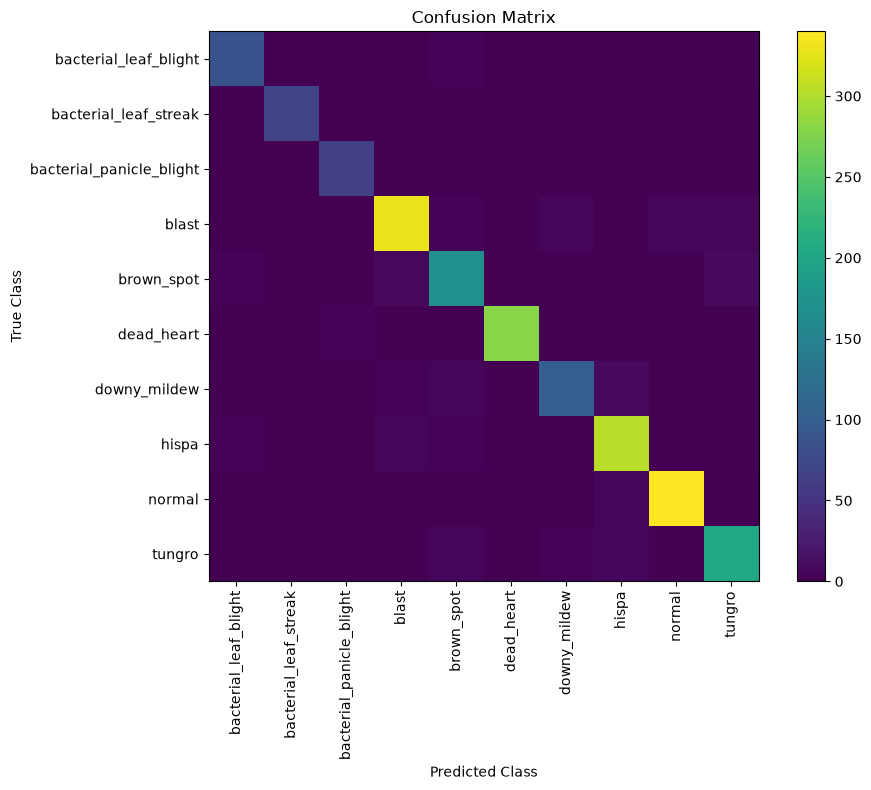

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(
    confusion_matrix,
    interpolation="nearest"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.colorbar()

plt.tight_layout()
plt.show()

#### Step 3: Get Normalized Confusion Matrix

In [15]:
normalized_confusion_matrix = (
    confusion_matrix.float()
    / confusion_matrix.sum(dim=1, keepdim=True)
)

print("Normalized Confusion Matrix:")
print(normalized_confusion_matrix)

Normalized Confusion Matrix:
tensor([[0.8958, 0.0104, 0.0000, 0.0104, 0.0312, 0.0104, 0.0104, 0.0104, 0.0000,
         0.0208],
        [0.0132, 0.9211, 0.0000, 0.0000, 0.0263, 0.0000, 0.0263, 0.0132, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.9552, 0.0000, 0.0000, 0.0299, 0.0000, 0.0149, 0.0000,
         0.0000],
        [0.0029, 0.0000, 0.0000, 0.9483, 0.0086, 0.0029, 0.0115, 0.0000, 0.0115,
         0.0144],
        [0.0155, 0.0000, 0.0000, 0.0363, 0.8808, 0.0000, 0.0052, 0.0104, 0.0104,
         0.0415],
        [0.0000, 0.0000, 0.0104, 0.0000, 0.0035, 0.9688, 0.0000, 0.0069, 0.0035,
         0.0069],
        [0.0161, 0.0081, 0.0000, 0.0242, 0.0484, 0.0000, 0.8226, 0.0645, 0.0000,
         0.0161],
        [0.0094, 0.0031, 0.0000, 0.0125, 0.0094, 0.0000, 0.0031, 0.9530, 0.0031,
         0.0063],
        [0.0000, 0.0000, 0.0057, 0.0028, 0.0028, 0.0057, 0.0000, 0.0170, 0.9632,
         0.0028],
        [0.0046, 0.0000, 0.0000, 0.0046, 0.0183, 0.0000, 0.0138, 0.0229, 0.0092,

So the picture is quite clear:

- Downy mildew is the weakest class by recall: 82.26%.
- brown_spot is next at 88.08%.
- bacterial_leaf_blight is 89.58%.
- The strongest are dead_heart (96.88%) and normal (96.32%).

And importantly, there isn't one disastrous confusion pair. downy_mildew, for example, has its errors spread across hispa, blast, brown_spot, etc.

#### Step 4: Visualize This Matrix

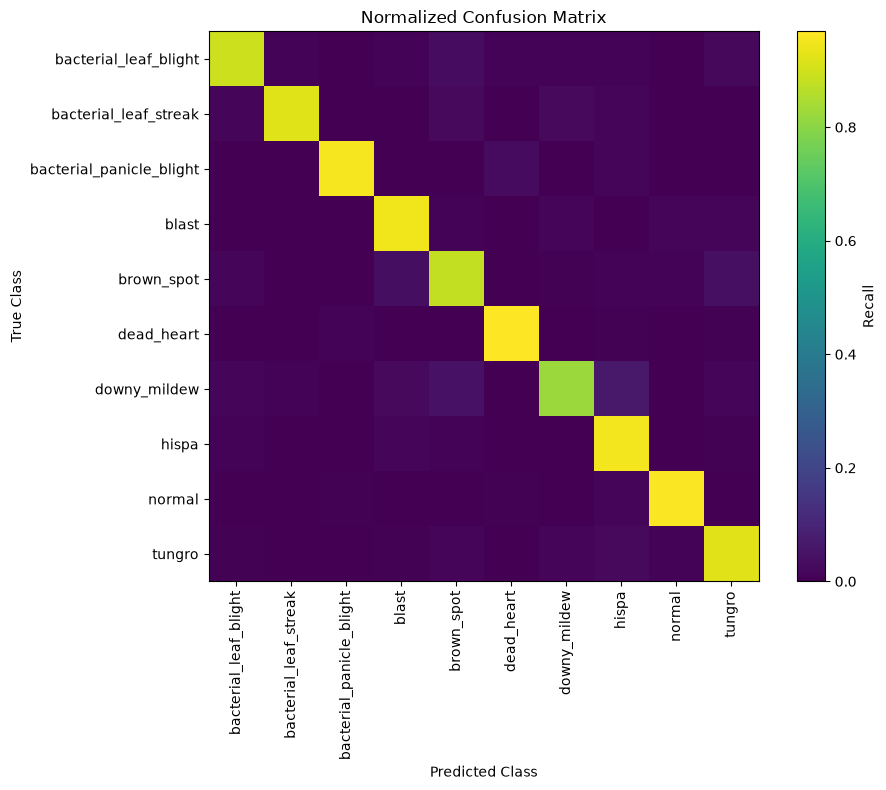

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(
    normalized_confusion_matrix,
    interpolation="nearest"
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.colorbar(label="Recall")

plt.tight_layout()
plt.show()

**Confusion Matrix Analysis**

The normalized confusion matrix shows that the Stage-6 fine-tuned
EfficientNetV2-S model performs well across all ten classes.

The strongest class-wise recall is observed for `dead_heart` and `normal`,
while `downy_mildew` is the most difficult class. The remaining errors are
distributed across several visually similar disease classes rather than
being concentrated in a single systematic confusion.

This suggests that the model has learned a strong class-discriminative
representation, while some residual errors may arise from visual
similarities between disease categories.

### 4.4: Compare The Three Experiments
| Model                   |   Accuracy |   Macro F1 |
| ----------------------- | ---------: | ---------: |
| Frozen EfficientNetV2-S |     68.88% |     65.63% |
| Fine-tune `[7:]`        |     70.80% |     67.36% |
| **Fine-tune `[6:]`**    | **93.52%** | **92.52%** |


## 5. Conclusion
The Stage-6 model achieved 93.52% validation accuracy and 92.52% macro F1. Although validation loss was still decreasing at epoch 12, further training was not pursued in this experiment because the model had already achieved strong validation performance and additional computational cost was substantial.